# 4 - Projectile Motion with Air Resistance

# Import Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
m = 20.0
c = 0.01
g = 9.80665
t = 10.0

x0, xn = 0.0, 1000.0
y0, yn = 0.0, 50.0

# Helper Functions

Methods here are implemented using purely Python and NumPy. These methods include calculating the norm, solving SLE problems, chebyshev points, etc.

In [3]:
def norm(x):
    """Returns the p=2 norm."""
    return np.sqrt(np.square(x).sum())

def augment_matrix(A, y):
    """Augments matrix A and vector y."""
    if A.shape[0] != y.shape[0]:
        raise ValueError(f'{A.shape[0]} not matching {y.shape[0]}')
    
    return np.c_[A, y].astype(np.float64)

def _ero1(A, i1, i2, verbose=True):
    """Performs elementary row operation I."""
    print(f'ERO1: R{i1} <-> R{i2}') if verbose else None
    A_ = A.copy()
    A_[[i1, i2]] = A_[[i2, i1]]
    return A_

def _ero2(A, i, k, verbose=True):
    """Performs elementary row operation II."""
    print(f'ERO2: R{i} <- {k} x R{i}') if verbose else None
    A_ = A.copy()
    A_[i] = k * A_[i]
    return A_

def _ero3(A, i1, i2, k, verbose=True):
    """Performs elementary row operation III."""
    print(f'ERO3: R{i1} <- R{i1} + {k} x R{i2}') if verbose else None
    A_ = A.copy()
    A_[i1] = A_[i1] + A_[i2] * k
    return A_

def rref(A, verbose=False, display_round=4):
    """Transforms augmented matrix A to its Reduced Row Echelon Form."""
    A_ = A.copy()
    rows = A.shape[0]

    for i in range(rows):

        if verbose:
            print(f'\nRow {i} (FROM)')
            print(np.round(A_, display_round))

        imax = np.argmax(np.abs(A_[i:, i]))+i
        A_ = _ero1(A_, i, imax, verbose)
        if A_[i, i] == 0:
            continue
        A_ = _ero2(A_, i, 1/A_[i, i], verbose)
        A_[i, i] = 1.0

        for j in range(rows):
            if j != i:
                k = A_[j, i]
                if k != 0:
                    A_ = _ero3(A_, j, i, -k, verbose)
        if verbose:
            print(f'Row {i} (TO)')
            print(np.round(A_, display_round))

    return A_

def solve_sle(A, b):
    """Solves the x in the Ax = b problem."""
    Ab = augment_matrix(A, b)
    Ab_rref = rref(Ab)
    return Ab_rref[:, -1]

def chebyshev(n, scale):
    """Generates chebyshev points based on scale and number of points."""
    k = np.arange(0, n+1)
    t_mapped = (scale/2)*(1 + np.cos(k*np.pi/n))
    return np.sort(t_mapped)


# Discussion of the problem

We are given the acceleration of a body under projectile motion where air resistance is modelled quadratically. The accelerations in both x and y components are presented as second-order differential equations:

$$
x''=-\frac{c}{m}\left( \sqrt{x'^2 + y'^2} \right) x' \\
y''=-g-\frac{c}{m}\left( \sqrt{x'^2 + y'^2} \right) y' \\
$$
Where \
$c$ pertains to air resistance coefficients, \
$m$ means the mass of the body, \
$x'$ and $y'$ are the velocities in the horizontal and vertical direction respectively, \
$g$ is the acceleration due to gravity and for this case is a constant equal to 9.80665 $m/s^2$, and \
$\sqrt{x'^2 + y'^2}$ can be interpreted as the resultant velocity.

We can see that by increasing the resultant velocity and/or the individual velocity components, the acceleration decreases. The value of $c$ also heavily dictates the effect to acceleration, that is, if $c$ is increased, any direct increase in velocity will have a strong counteracting deceleration. Eventually, we can see that across the lifecycle of the body's flight, the velocities, both x and y components together with the resultant, decreases.

If we assume that $c$ is 0, this simplifies to the case where projectile motion neglects any resistance to because of air. The acceleration differential equations results to $x''=0$ and $y''=-g$ showing that only gravity affects the motion of the projectile or body. Here, the horizontal velocity is constant and only stops upon impact to the ground.

In the case of the problem where the boundary values are provided in terms of distances--uses Dirichlet boundary conditions, gives us the idea that the initial speed and the angle of the body is what will adjust for any value of $c$. Let us say that we start with $c=0$ or the no-drag projectile motion, this could mean that the initial velocity and angle of release would be $V_{NoDrag}$ and $\theta_{NoDrag}$, and for other positive values of $c$, their corresponding velocities and angles should be larger and lower than $V_{NoDrag}$ and $\theta_{NoDrag}$ respectively to compensate for decelaration encountered along the flight. The initial angle here must be smaller to ensure that most of the velocity goes toward the horizontal component.

# Solving for the no-drag case

The equations for both x and y are given by:

$$
x(t) = v_{x0} t + x_0 \\
y(t) = -\frac{1}{2}gt^2 + v_{y0} t + y_0
$$

By solving the initial velocities
$$
v_{x0} = \frac{x_n - x_0}{t_n} = \frac{1000-0}{10} = 100 \\
v_{y0} = \frac{y_n - y_0 + \frac{1}{2}gt_n}{t_n} = \frac{50 - 0 + \frac{1}{2}(9.80665)(10)}{10} = 54.03325
$$

The resultant initial velocity is 
$$
v_0 = \sqrt{v_{x0}^2 + v_{y0}^2} = \sqrt{100^2 + 54.03325^2} = 113.66 \\
\theta_0 = \arctan{\frac{v_{y0}}{v_{x0}}} = \arctan{\frac{54.03325}{100}} = 23.38 \deg
$$

Hence, to meet the target range of 1000 meters at a height of 50m, assuming no air, then we need to throw the projectile at 113.66 $m/s$ at an angle of 23.38 degrees.

Now that the initial velocities have been calculated, we can now determine $x(t)$ and $y(t)$ as functions of $t \in [0, 10]$.

$$



$$



In [4]:
def nodrag_projectile_motion(t, x0, y0, xn, yn, tn, g=9.80665):
    """Returns the x and y coordinates of projectile motion with no drag."""
    vx0 = (xn - x0)/tn
    vy0 = ((yn - y0) + 0.5*g*tn**2)/tn
    
    v0 = np.sqrt(vx0**2 + vy0**2)
    x = np.vectorize(lambda t: vx0*t + x0)(t)
    y = np.vectorize(lambda t: -0.5*g*t**2 + vy0*t + y0)(t)

    theta0 = np.degrees(np.arctan(vy0/vx0))
    return x, y, v0, theta0


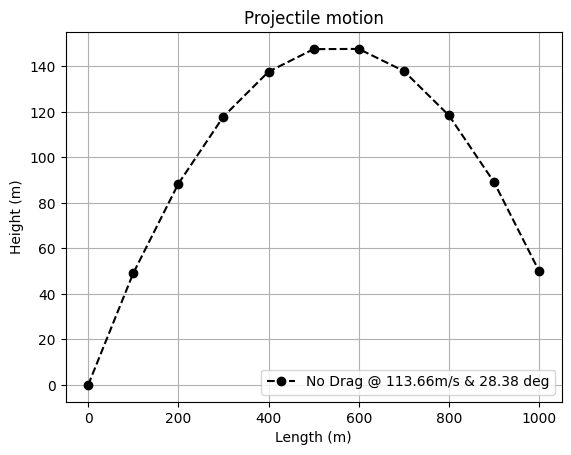

In [5]:
x_nd, y_nd, v0_nd, theta0_nd = nodrag_projectile_motion(
    t=np.arange(0, 11, 1), 
    x0=0, 
    y0=0, 
    xn=1000, 
    yn=50, 
    tn=10, 
)

plt.plot(x_nd, y_nd, 'k--o', label=f'No Drag @ {v0_nd:.2f}m/s & {theta0_nd:.2f} deg')
plt.legend()
plt.grid()
plt.ylabel('Height (m)')
plt.xlabel('Length (m)')
plt.title('Projectile motion')
plt.show()

This is the trajectory of the projectile when air resistance is very negligible. It is shown here that the trajectory is symmetric (assuming if the projectile would have continued until it hits the ground at y=0). The maximum height the projectile achieved is around ~150 meters.

# Basis Function is Multiquadric RBF

To use the collocation method, the selected basis function is the Multiquadric radial basis function defined by:

$$
\phi_j(x; x_j, \sigma) = \sqrt{(x-x_j)^2 + \sigma^2}
$$

where $x_j$ pertains to other points and $\sigma$ is a tunable parameter. For our case, $\sigma$ is is set to 1.0. This basis function was selected to have a smoother curve since this kind of basis function has a global support and influences points much farther from a given point.
The 1st and 2nd derivatives of is also defined in terms of the basis function itself.

$$
\phi_j'(x; x_j, \sigma) = \frac{(x-x_j)}{\phi_j(x; x_j, \sigma)}
$$

$$
\phi_j''(x; x_j, \sigma) = \frac{\sigma^2}{\phi_j(x; x_j, \sigma)^3}
$$

In [6]:
def basis_function(x, xj, sigma=1.):
    return np.sqrt((x - xj)**2 + sigma**2)

def basis_1st_derivative(x, xj, sigma=1.):
    return (x - xj)/basis_function(x, xj, sigma)

def basis_2nd_derivative(x, xj, sigma=1.):
    return sigma**2/basis_function(x, xj, sigma)**3


To minimize overfitting and be able to get smoother interpolation points, Chebyshev points are utilized and can be solved as:

$$
    t_{cheb} = \frac{x_{max}}{2} \left(1 + cos(\frac{k\pi}{n})\right)
$$

The system of equations that represents the problem are as follows:

$$
    \text{Equation that meets boundary conditions for x} \\
    \alpha \phi_j(t_0; t_{cheb}, 1) \\
    \alpha \phi_j(t_n; t_{cheb}, 1) - x_n \\

    \text{Equation that meets collocation points for x} \\
    \alpha \phi_j''(t_1; t_{cheb}, 1) + \frac{c}{m} v(t_1) v_x(t_1) \\
    \alpha \phi_j''(t_2; t_{cheb}, 1) + \frac{c}{m} v(t_2) v_x(t_2) \\
    \dots \\
    \alpha \phi_j''(t_{n-1}; t_{cheb}, 1) + \frac{c}{m} v(t_{n-1}) v_x(t_{n-1}) \\

    \text{Equation that meets boundary conditions for y} \\
    \beta \phi_j(t_0; t_{cheb}, 1) \\
    \beta \phi_j(t_n; t_{cheb}, 1) - y_n \\

    \text{Equation that meets collocation points for y} \\
    \beta \phi_j''(t_1; t_{cheb}, 1) + g + \frac{c}{m} v(t_1) v_x(t_1) \\
    \beta \phi_j''(t_2; t_{cheb}, 1) + g + \frac{c}{m} v(t_2) v_x(t_2) \\
    \dots \\
    \beta \phi_j''(t_{n-1}; t_{cheb}, 1) + g + \frac{c}{m} v(t_{n-1}) v_x(t_{n-1}) \\
$$

Here, for the X component equations, we have selected n-1 collocation points and 2 boundary points. Now for both X and Y, we have a total of 2n+2 points, hence 2n+2 equations needed to solve the system of equations.

Note here that the resultant velocity $v(t)=\sqrt{v_x(t)^2 + v_y(t)^2}$ was used to simplify the equations.

In [7]:
def residual(alpha, beta, c_nodes, sigma, x0, xn, y0, yn, c, m, g):
    """Function that returns the system of nonlinear equations that models the problem."""
    x = lambda t: alpha @ basis_function(t, c_nodes, sigma)
    y = lambda t: beta @ basis_function(t, c_nodes, sigma)

    vx = lambda t: alpha @ basis_1st_derivative(t, c_nodes, sigma)
    vy = lambda t: beta @ basis_1st_derivative(t, c_nodes, sigma)
    v = lambda t: np.sqrt(vx(t)**2 + vy(t)**2 + 1e-8)

    ax = lambda t: alpha @ basis_2nd_derivative(t, c_nodes, sigma)
    ay = lambda t: beta @ basis_2nd_derivative(t, c_nodes, sigma)
    
    t0, tn = c_nodes[0], c_nodes[-1]

    eq1x = x(t0) - x0
    eq2x = x(tn) - xn
    eq1y = y(t0) - y0
    eq2y = y(tn) - yn

    equations_x = [eq1x, eq2x]
    equations_y = [eq1y, eq2y]

    for t_node in c_nodes[1:-1]:
        equations_x.append(ax(t_node) + (c/m) * v(t_node) * vx(t_node))
        equations_y.append(ay(t_node) + g + (c/m) * v(t_node) * vy(t_node))

    return np.array(equations_x + equations_y)

def residual_flat(z, **kwargs):
    """Combines the x and y equations into 1 vector."""
    split = int(len(z)/2)
    alpha = z[:split]
    beta = z[split:]
    return residual(alpha, beta, **kwargs) 

The function below solves the SNLE problem using secant method. This was chosen to avoid analytically solving for the Jacobian and just solving for finite differences to approximate the Jacobian.

In [8]:
def secant_method(f, x_guess, tol=1e-8, max_iter=100, h=1e-4, **kwargs):
    n_iter = 0
    x = x_guess.astype(np.float64).copy()
    n=len(x)

    for _ in range(max_iter):
        n_iter += 1
        fx = f(x, **kwargs)

        norm_fx = norm(fx)
        if norm_fx <= tol:
            break
        J = np.zeros((n, n))
        for i in range(n):
            xh = x.copy()
            xh[i] += h
            J[:, i] = (f(xh, **kwargs) - fx)/h
        dx = solve_sle(J, -fx)
        x += dx
        
    return x[:int(n/2)], x[int(n/2):]

In [9]:
def initial_speed_angle(alpha, beta, t, chebyshev_points, sigma=1):
    """Returns a the initial velocity and initial angle based from the coefficients."""
    vx = alpha @ basis_1st_derivative(t, chebyshev_points, sigma)
    vy = beta @ basis_1st_derivative(t, chebyshev_points, sigma)
    vx0 = vx[0]
    vy0 = vy[0]
    v0 = np.sqrt(vx0**2 + vy0**2)
    theta0 = np.degrees(np.arctan(vy0/vx0))
    return v0, theta0

In [10]:
def velocity_values(alpha, beta, t, chebyshev_points, sigma=1):
    """Returns a the initial velocity and initial angle based from the coefficients."""
    vx = alpha @ basis_1st_derivative(t, chebyshev_points, sigma)
    vy = beta @ basis_1st_derivative(t, chebyshev_points, sigma)
    return vx, vy

def acceleration_values(alpha, beta, t, chebyshev_points, sigma=1):
    """Returns a the initial velocity and initial angle based from the coefficients."""
    ax = alpha @ basis_2nd_derivative(t, chebyshev_points, sigma)
    ay = beta @ basis_2nd_derivative(t, chebyshev_points, sigma)
    return ax, ay

# Solution at c = 0.01

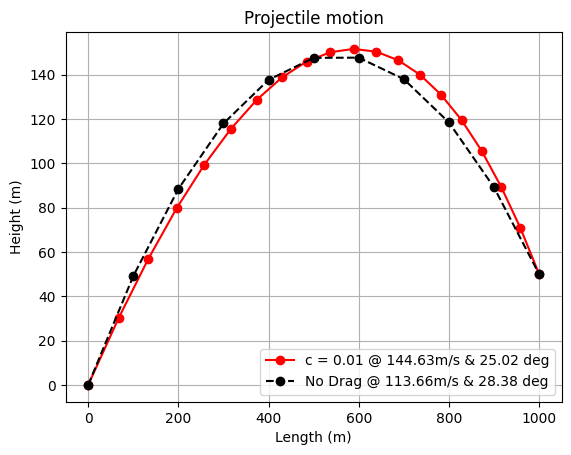

In [11]:
x_c1, y_c1 = secant_method(
    residual_flat,
    np.zeros(42),
    c_nodes=chebyshev(20, 10), 
    sigma=1, 
    x0=0, 
    xn=1000, 
    y0=0, 
    yn=50, 
    c=0.01, 
    m=20, 
    g=9.80665
)
v0_c1, theta0_c1 = initial_speed_angle(x_c1, y_c1, np.linspace(0, 10, 20), chebyshev(20, 10)[:, None])
vx_c1, vy_c1 = velocity_values(x_c1, y_c1, np.linspace(0, 10, 20), chebyshev(20, 10)[:, None])
ax_c1, ay_c1 = acceleration_values(x_c1, y_c1, np.linspace(0, 10, 20), chebyshev(20, 10)[:, None])

plt.plot(
    x_c1 @ basis_function(np.linspace(0, 10, 20), chebyshev(20, 10)[:, None], 1),
    y_c1 @ basis_function(np.linspace(0, 10, 20), chebyshev(20, 10)[:, None], 1),
    'r-o',
    label=f'c = 0.01 @ {v0_c1:.2f}m/s & {theta0_c1:.2f} deg'
)
plt.plot(x_nd, y_nd, 'k--o', label=f'No Drag @ {v0_nd:.2f}m/s & {theta0_nd:.2f} deg')
plt.legend()
plt.grid()
plt.ylabel('Height (m)')
plt.xlabel('Length (m)')
plt.title('Projectile motion')
plt.show()

Shown above is the plot of 2 cases of projectile motion, one has no drag, and the other one has $c=0.01$. For $c=0.01$, to ensure that the boundary conditions of 1000m range and 50m height are met, one must throw the projectile at a faster initial speed and lower angle granting the body enough velocity in its horizontal component. We can see here that the one with finite drag has achieved higher maximum height but decelerated faster upon reaching the maximum height--this is attributed to the fact that the projectile is now encountering higher drag due to the higher velocity thus deceleration is relatively stronger.

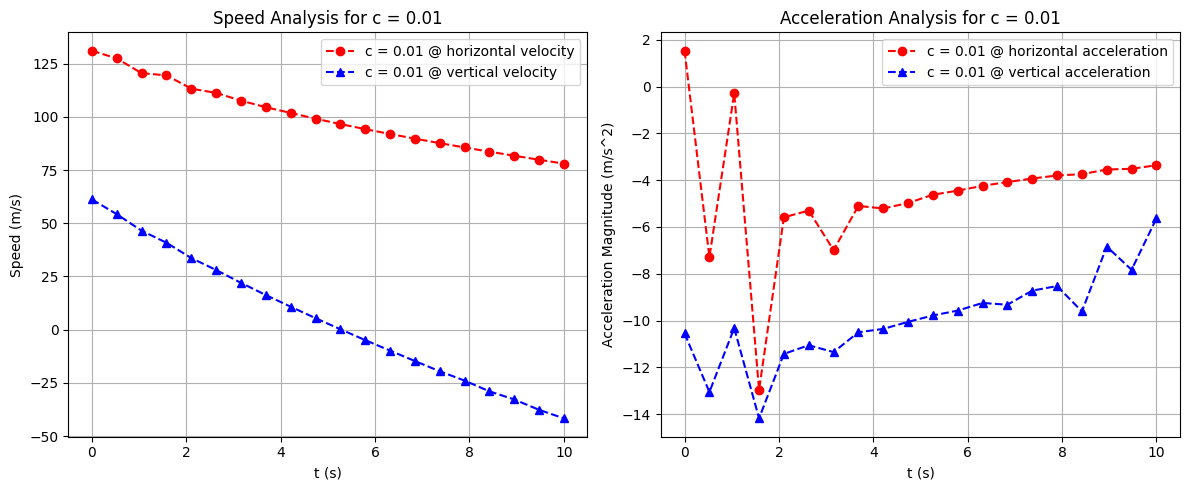

In [12]:
t = np.linspace(0, 10, 20)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, vx_c1, 'r--o', label='c = 0.01 @ horizontal velocity')
axes[0].plot(t, vy_c1, 'b--^', label='c = 0.01 @ vertical velocity')
axes[0].set_ylabel('Speed (m/s)')
axes[0].set_xlabel('t (s)')
axes[0].set_title('Speed Analysis for c = 0.01')
axes[0].legend()
axes[0].grid()

axes[1].plot(t, ax_c1, 'r--o', label='c = 0.01 @ horizontal acceleration')
axes[1].plot(t, ay_c1, 'b--^', label='c = 0.01 @ vertical acceleration')
axes[1].set_ylabel('Acceleration Magnitude (m/s^2)')
axes[1].set_xlabel('t (s)')
axes[1].set_title('Acceleration Analysis for c = 0.01')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

Shown above are plots showing the x and y components of both acceleration and velocity for a given time. For the velocity values, as expected because of air resistance (and gravity), the speeds decreases gradually. On the right plot, the maximum acceleration occurs at the start since this is the moment where you applied force to abruptly give the "boost" on the object. However, this acceleration tends to decrease until at around t=1s where this is the maximum deceleration. If one observes at the early phases of the trajectory, acceleration values tend to oscillate, this is because of the stiffness of the problem where slopes are high (because of the high acceleration). Nonetheless, the point here is that there comes a point that the deceleration smoothens or balances out the speeds. Although within the whole time span the acceleration did not approach 0--which would be the terminal velocity, we can still see that the trajectory approaches it.

# Solution at c in {0.005, 0.01, 0.05}

In [13]:
x_c2, y_c2 = secant_method(
    residual_flat,
    np.zeros(42),
    c_nodes=chebyshev(20, 10), 
    sigma=1, 
    x0=0, 
    xn=1000, 
    y0=0, 
    yn=50, 
    c=0.005, 
    m=20, 
    g=9.80665
)
v0_c2, theta0_c2 = initial_speed_angle(x_c2, y_c2, np.linspace(0, 10, 20), chebyshev(20, 10)[:, None])

x_c3, y_c3 = secant_method(
    residual_flat,
    np.zeros(42),
    c_nodes=chebyshev(20, 10), 
    sigma=1, 
    x0=0, 
    xn=1000, 
    y0=0, 
    yn=50, 
    c=0.01, 
    m=20, 
    g=9.80665
)
v0_c3, theta0_c3 = initial_speed_angle(x_c3, y_c3, np.linspace(0, 10, 20), chebyshev(20, 10)[:, None])

x_c4, y_c4 = secant_method(
    residual_flat,
    np.ones(42),
    c_nodes=chebyshev(20, 10), 
    sigma=1, 
    x0=0, 
    xn=1000, 
    y0=0, 
    yn=50, 
    c=0.05, 
    m=20, 
    g=9.80665
)
v0_c4, theta0_c4 = initial_speed_angle(x_c4, y_c4, np.linspace(0, 10, 20), chebyshev(20, 10)[:, None])
vx_c4, vy_c4 = velocity_values(x_c4, y_c4, np.linspace(0, 10, 20), chebyshev(20, 10)[:, None])
ax_c4, ay_c4 = acceleration_values(x_c4, y_c4, np.linspace(0, 10, 20), chebyshev(20, 10)[:, None])

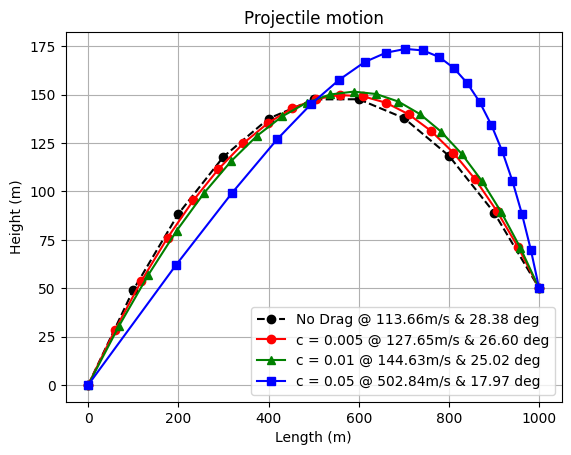

In [14]:
plt.plot(x_nd, y_nd, 'k--o', label=f'No Drag @ {v0_nd:.2f}m/s & {theta0_nd:.2f} deg')
plt.plot(
    x_c2 @ basis_function(np.linspace(0, 10, 20), chebyshev(20, 10)[:, None], 1),
    y_c2 @ basis_function(np.linspace(0, 10, 20), chebyshev(20, 10)[:, None], 1),
    'r-o',
    label=f'c = 0.005 @ {v0_c2:.2f}m/s & {theta0_c2:.2f} deg'
)

plt.plot(
    x_c3 @ basis_function(np.linspace(0, 10, 20), chebyshev(20, 10)[:, None], 1),
    y_c3 @ basis_function(np.linspace(0, 10, 20), chebyshev(20, 10)[:, None], 1),
    'g-^',
    label=f'c = 0.01 @ {v0_c3:.2f}m/s & {theta0_c3:.2f} deg'
)

plt.plot(
    x_c4 @ basis_function(np.linspace(0, 10, 20), chebyshev(20, 10)[:, None], 1),
    y_c4 @ basis_function(np.linspace(0, 10, 20), chebyshev(20, 10)[:, None], 1),
    'b-s',
    label=f'c = 0.05 @ {v0_c4:.2f}m/s & {theta0_c4:.2f} deg'
)

plt.legend()
plt.grid()
plt.ylabel('Height (m)')
plt.xlabel('Length (m)')
plt.title('Projectile motion')
plt.show()

Three (3) different values of $c$ were used to solve the problem. As shown, the higher the value of $c$, the higher initial velocity is needed to counteract the deceleration expected. Similarly, a lower initial trajectory angle is needed to maximize the horizontal velocity needed. While one can argue that for the $c$ values {0.01 amd 0.05}, results are somewhat comparable with the no drag case, the case of $c=0.05$ has a more pronounced impact. One must throw the projectile at ~5x the original velocity just to hit the same target point. Because of this high velocity, the object is able to achieve higher maximum height at around ~175 but decelerated at a more abrupt rate compared to other cases.

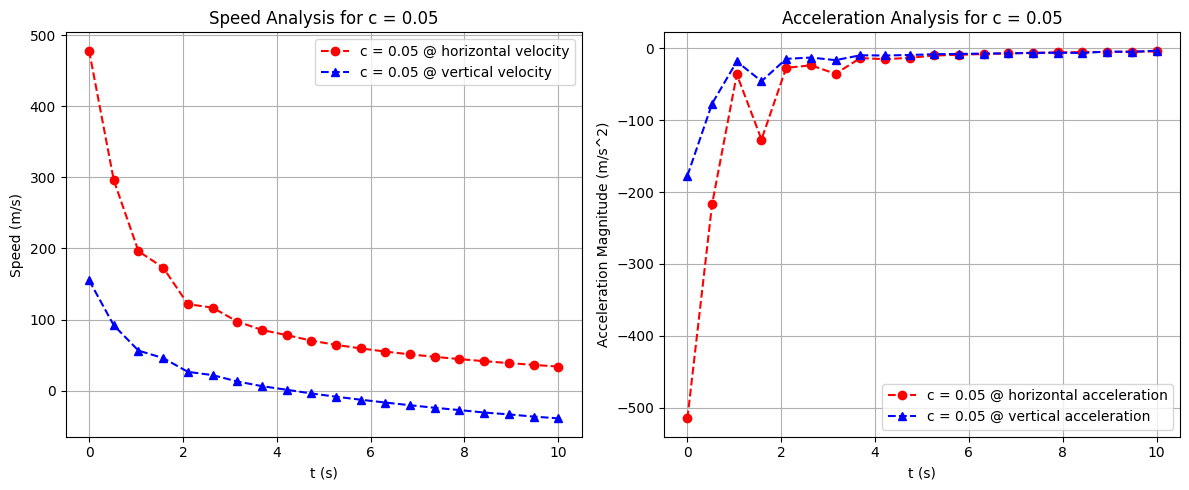

In [15]:
t = np.linspace(0, 10, 20)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, vx_c4, 'r--o', label='c = 0.05 @ horizontal velocity')
axes[0].plot(t, vy_c4, 'b--^', label='c = 0.05 @ vertical velocity')
axes[0].set_ylabel('Speed (m/s)')
axes[0].set_xlabel('t (s)')
axes[0].set_title('Speed Analysis for c = 0.05')
axes[0].legend()
axes[0].grid()

axes[1].plot(t, ax_c4, 'r--o', label='c = 0.05 @ horizontal acceleration')
axes[1].plot(t, ay_c4, 'b--^', label='c = 0.05 @ vertical acceleration')
axes[1].set_ylabel('Acceleration Magnitude (m/s^2)')
axes[1].set_xlabel('t (s)')
axes[1].set_title('Acceleration Analysis for c = 0.05')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

Shown above is the same speed and acceleration analysis but now for the higher value of $c$ which is $c=0.05$. As shown here, the curves are much steeper for the early phases, but the trend is similar to the $c=0.01$. Speed values start out high but decrease very steeply and then gradually decrease around t=2s. This can be explained by the acceleration plots. Similar to $c=0.01$, there are oscillations on the early part due to problem stiffness, and then stabilizes until acceleration approaches 0 where air resistance has now balanced out the speeds.

# Conclusion

The initial speed and initial angle for $c=0.01 kg/m$ is 143.50m/s and 24.95 degrees. When compared with no-drag case, initial speed and initial angle are 113.66 m/s and 28.38 degrees. For increasing values of $c$ or the coefficient of air resisntance, it can be generalized that a higher initial speed and lower initial angle is required to hit the given boundary conditions of range and height. This is because higher velocity or speed is needed to counteract the air resistances. As described by the differential equations for acceleration, the higher the velocity, the higher will be the deceleration. Based on the speed and acceleration analysis plots, speed generally has a steep decrease as this is the point where speed is near max hence deceleration is also relatively strongest. While oscillations of the acceleration might be due to numerical instabilities, we can see that this acceleration or deceleration magnitude starts to approach zero where the current speed is now stable. This may also be known as terminal speed.

While in this problem it is assumed that $c$ is constant for a given case, this is usually not true. Drag coefficients generally depends on a lot of factors such as Mach Number, Reynold's Number--where both depends on speed and air properties. This means that $c$ is usually a factor of speed also. While at low speeds where speed is incompressible (rule of thumb is that Mach number is less than 0.3), this can be negligible. However for compressible flow such as the case of $c=0.05$ where initial speed is already around 500m/s, this is already within the supersonic flow regime and shock waves would be present, therefore the differential equation models for acceleration would be invalid. In practice, assuming that flow is still not supersonic, aerodynamics forces are usually calculated as $F=\frac{1}{2} C \rho v^2 S$ where $\rho$ is density of air and $S$ is some reference area of the object. This equation still shows that the acceleration due to aerodynamic force depends on the square of the object's speed. Therefore the $c$ in the original problem is a simplification of $\frac{1}{2} C \rho S$. $C$ on this case as stated before, depends on a lot of factors, but also depends on the object's orientation with respect to its trajectory, hence could increase or decrease. Hence to increase robustness of this solution, a good way to improve it is to define some function $c(t)$ such that we can model the problem more accurately, albeit a difficult problem.

Another extension is since this problem assumes a projectile that is a point rigid object, real life objects have finite dimensions and also deforms. Because of having finite dimension and deformability, aerodynamic moments also play a big role here such that it affects rotation motion and the object's orientation which in turn affects $c$. One more thing, as state above that $c$ also depends on $\rho$ or air's density, this would also play a major impact. As an object's altitude increases, density decreases hence would impact the value of $c$.

There are a lot of factors that affect the value of $c$. But the point here is that if we can model $c$ accurately, we can have a robust model against air resistance. This is usually a difficult problem hence the different kinds of assumptions, but nonetheless, squared velocity for predicting aerodynamic force is accepted by many to be the correct approach.

Applications of this problem usually includes bullet ballistics, sports physics e.g., golf, table tennis, basketball, etc, aerospace vehicles, and a lot more! Being able to improve this solution would be very helpful in different problems. Not only is this useful for aerodynamic flows, it can be extended to other fluid flows such as boats and hydrodynamic vehicles, or even in medical fields like in blood flow.

